<h1 style="text-align:center;">Voting Access in Colorado - Geospatial Analysis of the 2024 Presidential Election</h1>

This analysis explores geographic access to voting locations across Colorado counties using spatial data. The goal is to quantify differences in access between regions and evaluate potential disparities in travel distance to voting sites.

In [97]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
print(gpd.__version__)

1.1.3


# Import Cleaned Datasets

In [13]:
county_df = pd.read_csv("data/colorado_voter_data_by_county_2024.csv")
location_df = pd.read_csv("data/colorado_voter_data_by_location_2024.csv")

print("------------------------------Head of County Voting Dataset-----------------------------------")
print(county_df.head())
print("                                                                                              ")
print("-----------------------------Head of Voting Location Dataset----------------------------------")
print(location_df.head())

------------------------------Head of County Voting Dataset-----------------------------------
      county  num_sites  population  registered voters  democrat  republican  \
0      Adams         49      543760             320225    124056      103024   
1    Alamosa          4       16632              10321      3244        4057   
2   Arapahoe         49      666557             426537    190725      125311   
3  Archuleta          5       14137              11705      3904        5218   
4       Baca          3        3398               2582       275        1686   

   other  total votes  
0   6256       233336  
1    218         7519  
2   9415       325451  
3    233         9355  
4     43         2004  
                                                                                              
-----------------------------Head of Voting Location Dataset----------------------------------
              X             Y   county         site_type  \
0 -1.162854e+07  4.771434e+06 

# Import Colorado Map Data

In [17]:
counties = gpd.read_file("data/tl_2024_us_county/tl_2024_us_county.shp")

# Filter for Colorado, STATEFP = '08'
counties = counties[counties["STATEFP"] == "08"]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
22,08,109,00198170,08109,0500000US08109,Saguache,Saguache County,06,H1,G4020,None,None,None,A,8206547700,4454510,+38.0316514,-106.2346662,"POLYGON ((-107.00189 38.09291, -107.00188 38.0..."
105,08,115,00198173,08115,0500000US08115,Sedgwick,Sedgwick County,06,H1,G4020,None,None,None,A,1419419024,3530746,+40.8715679,-102.3553579,"POLYGON ((-102.65349 40.99999, -102.65348 41.0..."
122,08,017,00198124,08017,0500000US08017,Cheyenne,Cheyenne County,06,H1,G4020,None,None,None,A,4605713958,8166129,+38.8356456,-102.6017914,"POLYGON ((-102.54698 38.61343, -102.54734 38.6..."
161,08,027,00198129,08027,0500000US08027,Custer,Custer County,06,H1,G4020,None,None,None,A,1913031985,3364150,+38.1019955,-105.3735123,"POLYGON ((-105.7969 38.26505, -105.78341 38.26..."
198,08,067,00198148,08067,0500000US08067,La Plata,La Plata County,06,H1,G4020,None,20420,None,A,4376255274,25642579,+37.2873673,-107.8397178,"POLYGON ((-107.7124 36.99999, -107.71257 36.99..."


In [18]:
# Match coordinate systems
counties = counties.to_crs(epsg=4326)
counties["county"] = counties["NAME"].str.strip()

## Create GeoDataFrame

In [20]:
gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(location_df["X"], location_df["Y"]),
    crs="EPSG:3857"
)

# Convert to lat/lon for mapping
gdf = gdf.to_crs(epsg=4326)

gdf.head()

,X,Y,county,site_type,geocoded_address,population,registered voters,democrat,republican,other,total votes,geometry
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117",29337,23981,4768,15209,440,20417,POINT (-104.46091 39.34655)
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107",29337,23981,4768,15209,440,20417,POINT (-104.5968 39.36098)
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138",29337,23981,4768,15209,440,20417,POINT (-104.64448 39.46517)
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)


## Assign Voting Locations to County

In [21]:
gdf = gpd.sjoin(gdf, counties, how="left", predicate="within")

## Examine Party Affliation and Voting Locations By County 

In [114]:
# merge counties with county_df
county_merged = counties.merge(county_df, on="county", how="left")

# Compute a normalized difference of vote
county_merged["dem_share"] = county_merged["democrat"]/county_merged["total votes"]
county_merged["rep_share"] = county_merged["republican"]/county_merged["total votes"]

# Coded for heatmap so (+) = democratic leaning and (-) = republican leaning
county_merged["partisan_lean"] = county_merged["dem_share"] - county_merged["rep_share"]

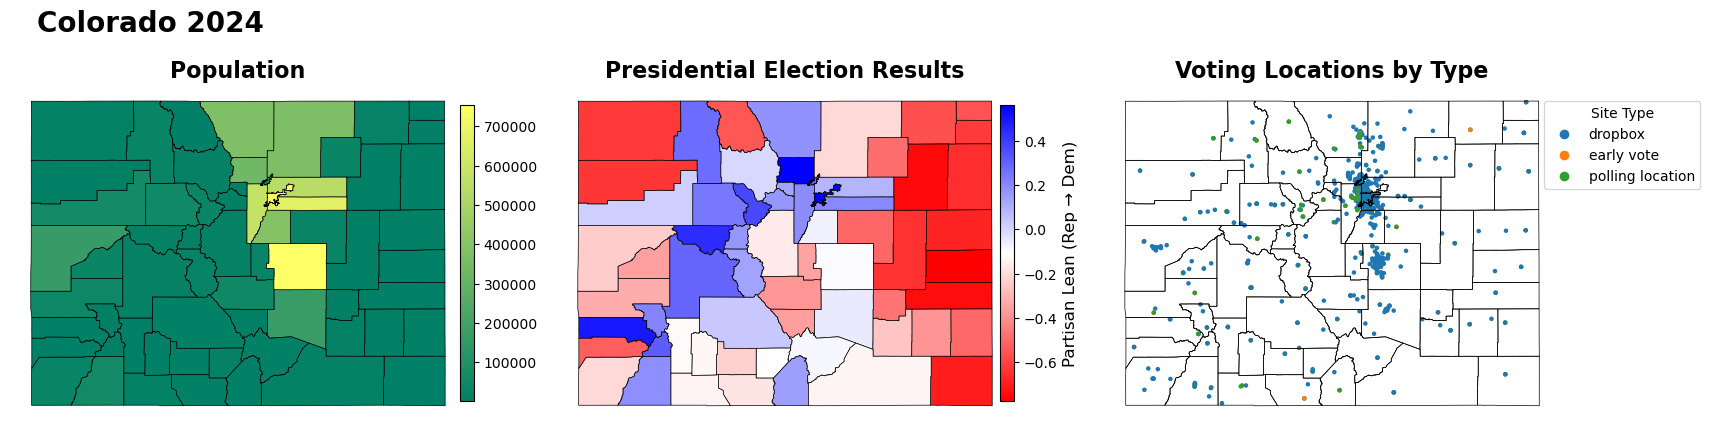

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(20,8))

#------------------------Population Plot--------------------------
cax_pop = fig.add_axes([0.35, 0.31, 0.007, 0.37])

county_merged.plot(
    column="population",
    cmap="summer",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0],
    cax=cax_pop
)

axes[0].set_title(
    "Population",
    fontweight='bold',
    fontsize=16
)
axes[0].axis("off")
# Colorbar label
#cax_pop.set_ylabel("Population (Low → High)", fontsize=12)


#----------------Voting Results by County Plot---------------------

cax_party = fig.add_axes([0.62, 0.31, 0.007, 0.37])

county_merged.plot(
    column="partisan_lean",
    cmap="bwr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    cax=cax_party,
    ax=axes[1]
)

axes[1].set_title(
    "Presidential Election Results",
    fontweight='bold',
    fontsize=16
)
axes[1].axis("off")
# Colorbar label
cax_party.set_ylabel("Partisan Lean (Rep → Dem)", fontsize=12)

#------------------- Voting Locations Plot-----------------------

# Set color of site types to match legend
color_map = {
    "dropbox": "#1f77b4",          # blue
    "early vote": "#ff7f0e",       # orange
    "polling location": "#2ca02c"  # green
}

gdf["color"] = gdf["site_type"].map(color_map)

gdf.plot(
    color=gdf["color"],
    markersize=5,
    ax=axes[2]
)

# Add county boundries
counties.boundary.plot(ax=axes[2], linewidth=0.5, color="black")

# Create color mapping 
colors = plt.cm.tab10(range(len(site_order)))

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=site,
           markerfacecolor=color_map[site],
           markersize=8)
    for site in site_order
]

axes[2].legend(
    handles=legend_elements,
    title="Site Type",
    loc="upper left",
    bbox_to_anchor=(0.95, 0.975)
)

axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(axes[0].get_ylim())

axes[2].set_xlim(axes[0].get_xlim())
axes[2].set_ylim(axes[0].get_ylim())

axes[2].set_title(
    "Voting Locations by Type", 
    fontweight='bold',
    fontsize=16
)

axes[2].axis("off")

fig.suptitle("Colorado 2024", fontweight='bold', fontsize=20, y=0.8, x=0.195)
# save option
plt.savefig('results/colorado_county_maps_election_results_voting_locations_population_2024.png')
plt.show()